Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: 12679 observations | 1975-01-03 → 2026-04-16


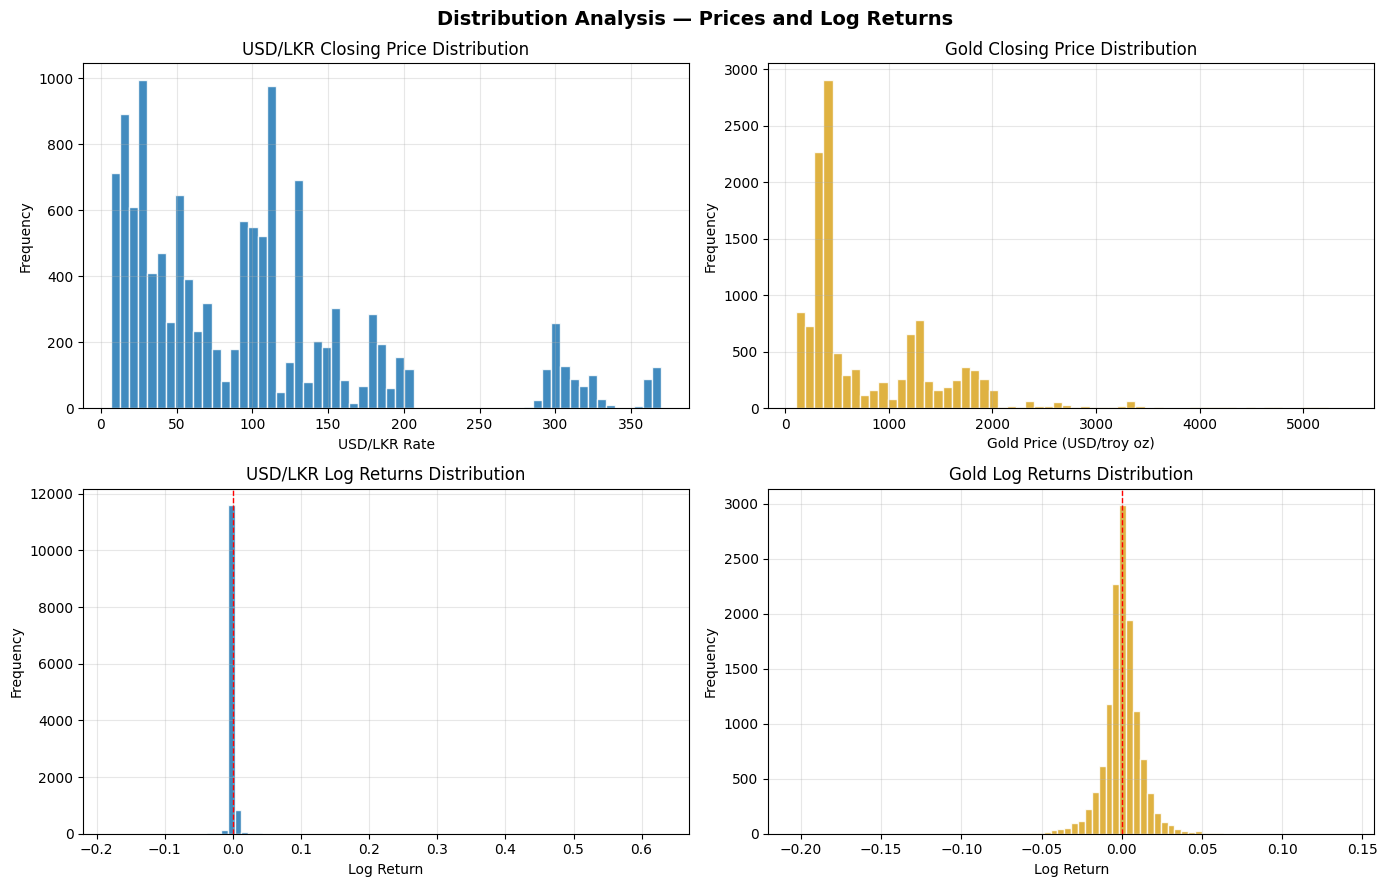


 Descriptive Statistics 
        lkr_close  gold_close  lkr_returns  gold_returns
count  12679.0000  12679.0000   12679.0000    12679.0000
mean      99.0346    838.7353       0.0003        0.0003
std       84.2229    761.0640       0.0072        0.0124
min        6.4940    102.8000      -0.1795       -0.2032
25%       30.4400    343.4250      -0.0001       -0.0050
50%       90.2000    433.2000       0.0000        0.0002
75%      130.8175   1268.6150       0.0005        0.0058
max      370.0000   5415.1700       0.6290        0.1400

LKR returns skewness : 53.2397
Gold returns skewness: -0.2931
LKR returns kurtosis : 4652.4950
Gold returns kurtosis: 15.0354


In [6]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller, grangercausalitytests, coint
from statsmodels.tsa.seasonal import STL

# LOAD CLEANED DATASET
# Now spans the full 1975-2026 history (12,680 rows) following the switch
# to the Stooq gold dataset, which fully overlaps the USD/LKR date range.

df = pd.read_csv(
    '/content/drive/MyDrive/MSc_Project/data/processed/usd_lkr_gold_cleaned.csv',
    index_col='Date',
    parse_dates=True
)

# Compute log returns (required for all statistical tests)
df['lkr_returns']  = np.log(df['lkr_close']  / df['lkr_close'].shift(1))
df['gold_returns'] = np.log(df['gold_close'] / df['gold_close'].shift(1))
df = df.dropna()

print(f"Dataset loaded: {df.shape[0]} observations | "
      f"{df.index.min().date()} → {df.index.max().date()}")

# EDA 1: DISTRIBUTION OF PRICES & RETURNS

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Distribution Analysis — Prices and Log Returns',
             fontsize=14, fontweight='bold')

# LKR price distribution
axes[0, 0].hist(df['lkr_close'], bins=60, color='#1f77b4', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('USD/LKR Closing Price Distribution')
axes[0, 0].set_xlabel('USD/LKR Rate')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Gold price distribution
axes[0, 1].hist(df['gold_close'], bins=60, color='#DAA520', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Gold Closing Price Distribution')
axes[0, 1].set_xlabel('Gold Price (USD/troy oz)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# LKR log returns distribution
axes[1, 0].hist(df['lkr_returns'], bins=80, color='#1f77b4', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('USD/LKR Log Returns Distribution')
axes[1, 0].set_xlabel('Log Return')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].grid(True, alpha=0.3)

# Gold log returns distribution
axes[1, 1].hist(df['gold_returns'], bins=80, color='#DAA520', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Gold Log Returns Distribution')
axes[1, 1].set_xlabel('Log Return')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Project/outputs/02a_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print descriptive stats
print("\n Descriptive Statistics ")
desc = df[['lkr_close', 'gold_close', 'lkr_returns', 'gold_returns']].describe().round(4)
print(desc)

print(f"\nLKR returns skewness : {df['lkr_returns'].skew():.4f}")
print(f"Gold returns skewness: {df['gold_returns'].skew():.4f}")
print(f"LKR returns kurtosis : {df['lkr_returns'].kurt():.4f}")
print(f"Gold returns kurtosis: {df['gold_returns'].kurt():.4f}")



#### Interpretation note
* LKR price: extremely right-skewed - the 1975-1977 pegged-rate era produces a
            long flat run near zero, and the 2022 crisis adds an extreme tail.
* Gold price: left-skewed across a much wider range now that 50 years of
             history are included, from the ~300s in the 1970s-90s up to
             the >5,000 levels reached by 2026.
* Log returns: LKR returns are now extremely leptokurtic (skew ≈ 53, kurtosis
              ≈ 4,650) - this is a direct consequence of the 1975-1977 fixed
              exchange rate period, where daily returns were ~0 for long
              stretches, combined with the extreme 2022 depreciation tail.
              This is a much more extreme distribution than the 2000-2022
              subset previously examined, and confirms the LKR series
              contains genuine regime changes that models must account for.
* Gold returns: kurtosis : 15.0, skew : -0.29 - still fat-tailed but far closer
               to typical financial-asset behaviour than the LKR series.

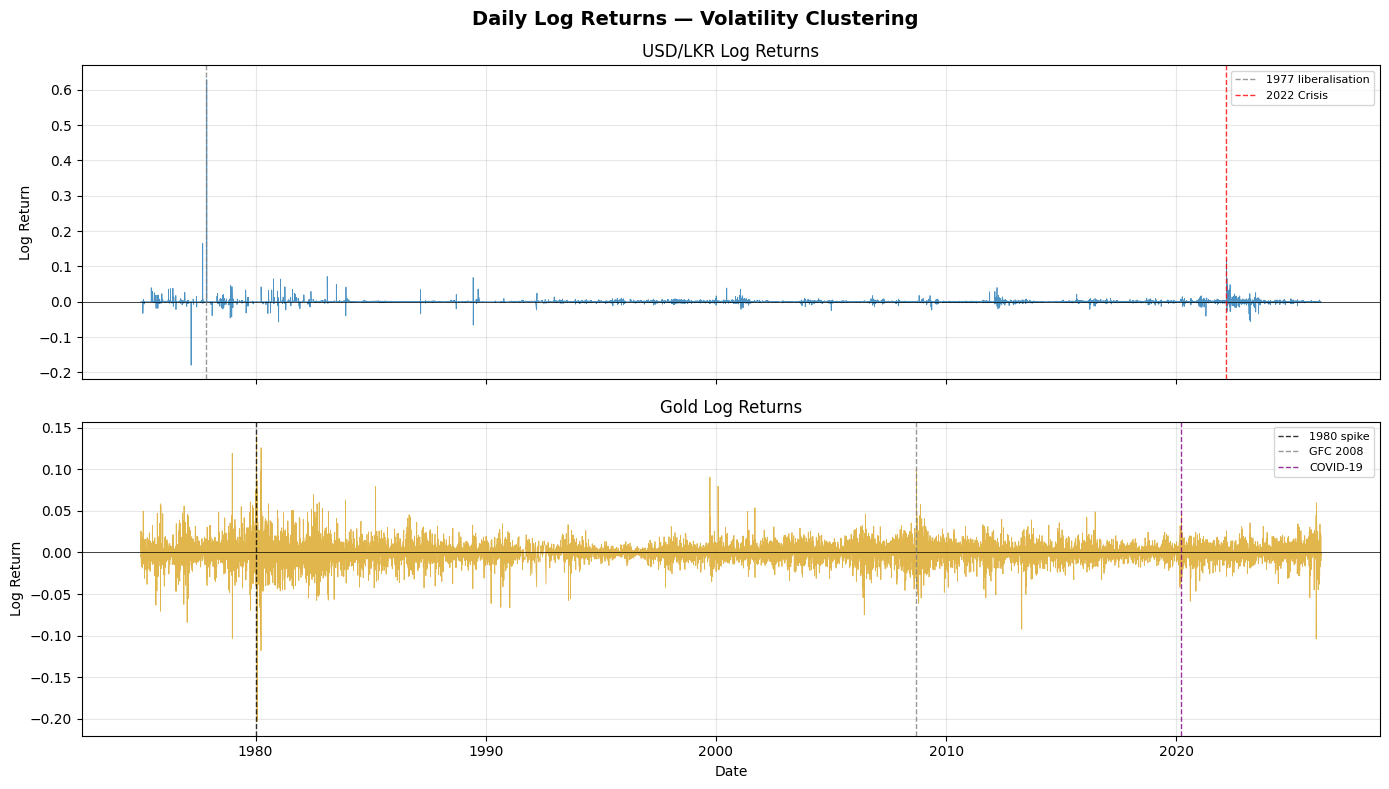

In [7]:
# EDA 2: LOG RETURNS TIME SERIES — VOLATILITY CLUSTERING

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Daily Log Returns — Volatility Clustering',
             fontsize=14, fontweight='bold')

axes[0].plot(df.index, df['lkr_returns'], color='#1f77b4', linewidth=0.6, alpha=0.8)
axes[0].set_ylabel('Log Return')
axes[0].set_title('USD/LKR Log Returns')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(pd.Timestamp('1977-11-01'), color='grey', linestyle='--',
                linewidth=1, alpha=0.8, label='1977 liberalisation')
axes[0].axvline(pd.Timestamp('2022-03-01'), color='red', linestyle='--',
                linewidth=1, alpha=0.8, label='2022 Crisis')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['gold_returns'], color='#DAA520', linewidth=0.6, alpha=0.8)
axes[1].set_ylabel('Log Return')
axes[1].set_title('Gold Log Returns')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axvline(pd.Timestamp('1980-01-01'), color='black', linestyle='--',
                linewidth=1, alpha=0.8, label='1980 spike')
axes[1].axvline(pd.Timestamp('2008-09-15'), color='grey', linestyle='--',
                linewidth=1, alpha=0.8, label='GFC 2008')
axes[1].axvline(pd.Timestamp('2020-03-11'), color='purple', linestyle='--',
                linewidth=1, alpha=0.8, label='COVID-19')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Project/outputs/02b_log_returns.png',
            dpi=150, bbox_inches='tight')
plt.show()



#### Interpretation note
* The LKR panel now clearly shows a flat, near-zero-volatility stretch from
1975-1977 (fixed exchange rate), followed by low but non-zero daily
movement after liberalisation, and then the extreme spike in 2022 that
dwarfs all prior activity. The gold panel shows volatility clustering
around all three major events (1980, 2008, 2020), confirming gold behaves
as a continuously-traded asset throughout, in contrast to the LKR's
policy-driven quiet periods. This justifies the use of GARCH to capture
time-varying volatility, and confirms the 2022 LKR crisis should be
treated as a structural break rather than ordinary volatility.

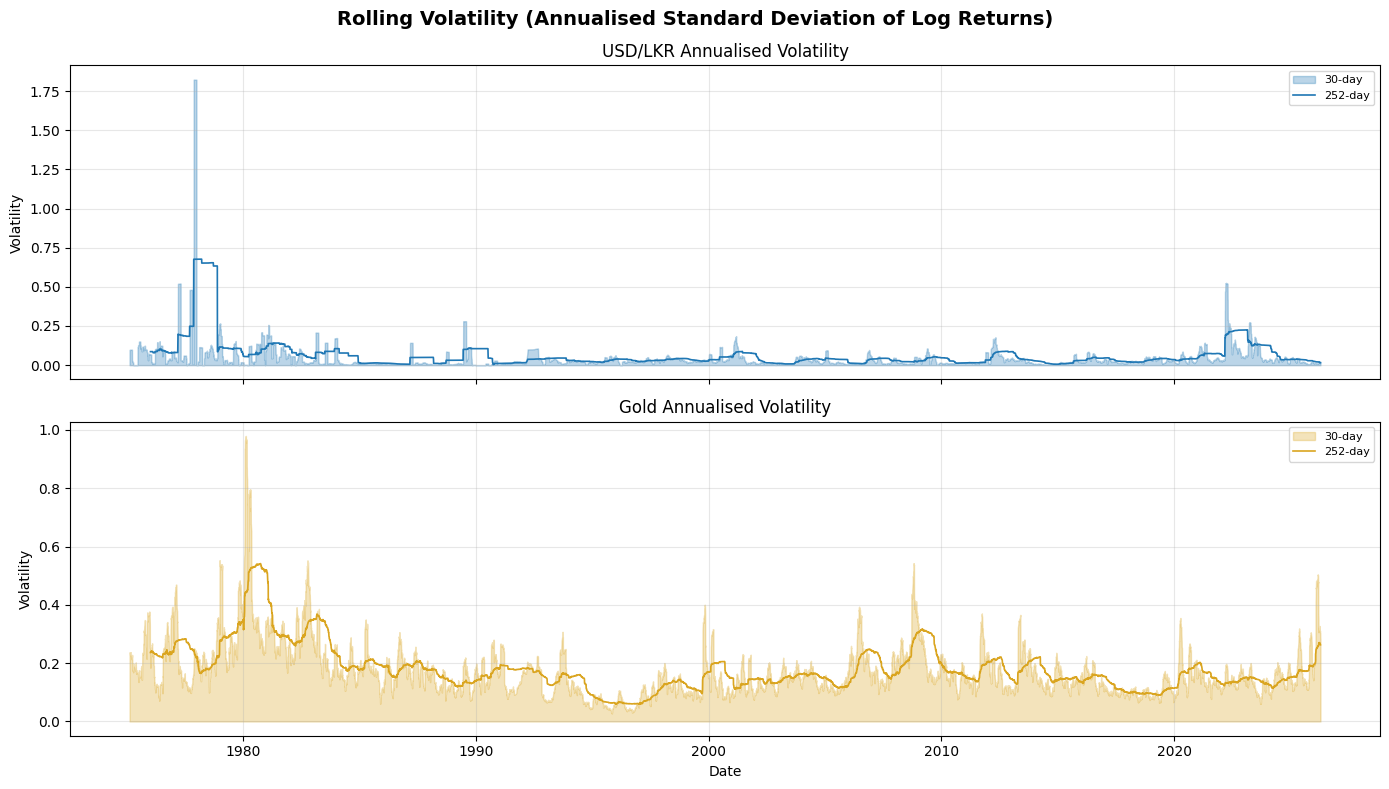

In [8]:
# EDA 3: ROLLING VOLATILITY (30-day & 252-day)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Rolling Volatility (Annualised Standard Deviation of Log Returns)',
             fontsize=14, fontweight='bold')

lkr_vol_30  = df['lkr_returns'].rolling(30).std()  * np.sqrt(252)
lkr_vol_252 = df['lkr_returns'].rolling(252).std() * np.sqrt(252)
gold_vol_30  = df['gold_returns'].rolling(30).std()  * np.sqrt(252)
gold_vol_252 = df['gold_returns'].rolling(252).std() * np.sqrt(252)

axes[0].fill_between(df.index, lkr_vol_30, alpha=0.3, color='#1f77b4', label='30-day')
axes[0].plot(df.index, lkr_vol_252, color='#1f77b4', linewidth=1.2, label='252-day')
axes[0].set_title('USD/LKR Annualised Volatility')
axes[0].set_ylabel('Volatility')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(df.index, gold_vol_30, alpha=0.3, color='#DAA520', label='30-day')
axes[1].plot(df.index, gold_vol_252, color='#DAA520', linewidth=1.2, label='252-day')
axes[1].set_title('Gold Annualised Volatility')
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Project/outputs/02c_rolling_volatility.png',
            dpi=150, bbox_inches='tight')
plt.show()



##### Interpretation note
* The 252-day LKR volatility line stays close to zero for almost the entire
 1975-2020 period, then rises sharply from 2020 onward, peaking dramatically
 in 2022 - a structural regime shift not visible in the shorter 2000-2022
 window previously examined. Gold maintains consistently higher baseline
 volatility throughout the full 50-year history, with visible peaks at 1980,
 2008, and 2020.


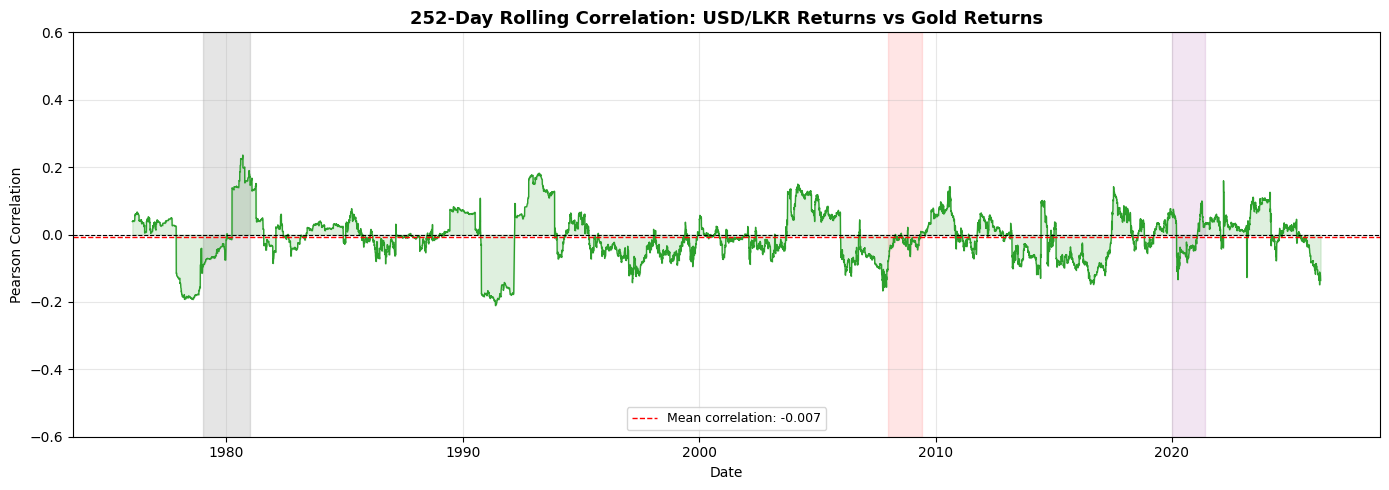

In [9]:
# EDA 4: ROLLING CORRELATION (252-day window)

rolling_corr = df['lkr_returns'].rolling(252).corr(df['gold_returns'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, rolling_corr, color='#2ca02c', linewidth=1.0)
ax.fill_between(df.index, rolling_corr, 0, alpha=0.15, color='#2ca02c')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(rolling_corr.mean(), color='red', linewidth=1,
           linestyle='--', label=f'Mean correlation: {rolling_corr.mean():.3f}')
ax.set_title('252-Day Rolling Correlation: USD/LKR Returns vs Gold Returns',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Pearson Correlation')
ax.set_xlabel('Date')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.6, 0.6)

# Annotate key periods
ax.axvspan(pd.Timestamp('1979-01-01'), pd.Timestamp('1981-01-01'),
           alpha=0.1, color='black', label='1980 spike period')
ax.axvspan(pd.Timestamp('2008-01-01'), pd.Timestamp('2009-06-01'),
           alpha=0.1, color='red', label='GFC period')
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-06-01'),
           alpha=0.1, color='purple', label='COVID period')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Project/outputs/02d_rolling_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()



##### Interpretation note
* With the full 50-year history, the rolling correlation continues to
 oscillate between positive and negative — confirming the relationship
 between gold and LKR is NOT static across the entire historical record,
 not just the 2000-2022 window. A single full-sample correlation figure
 would be misleading; the relationship is regime-dependent and tends to
 shift around global stress events, consistent with the safe-haven theory.


 STL Decomposition 


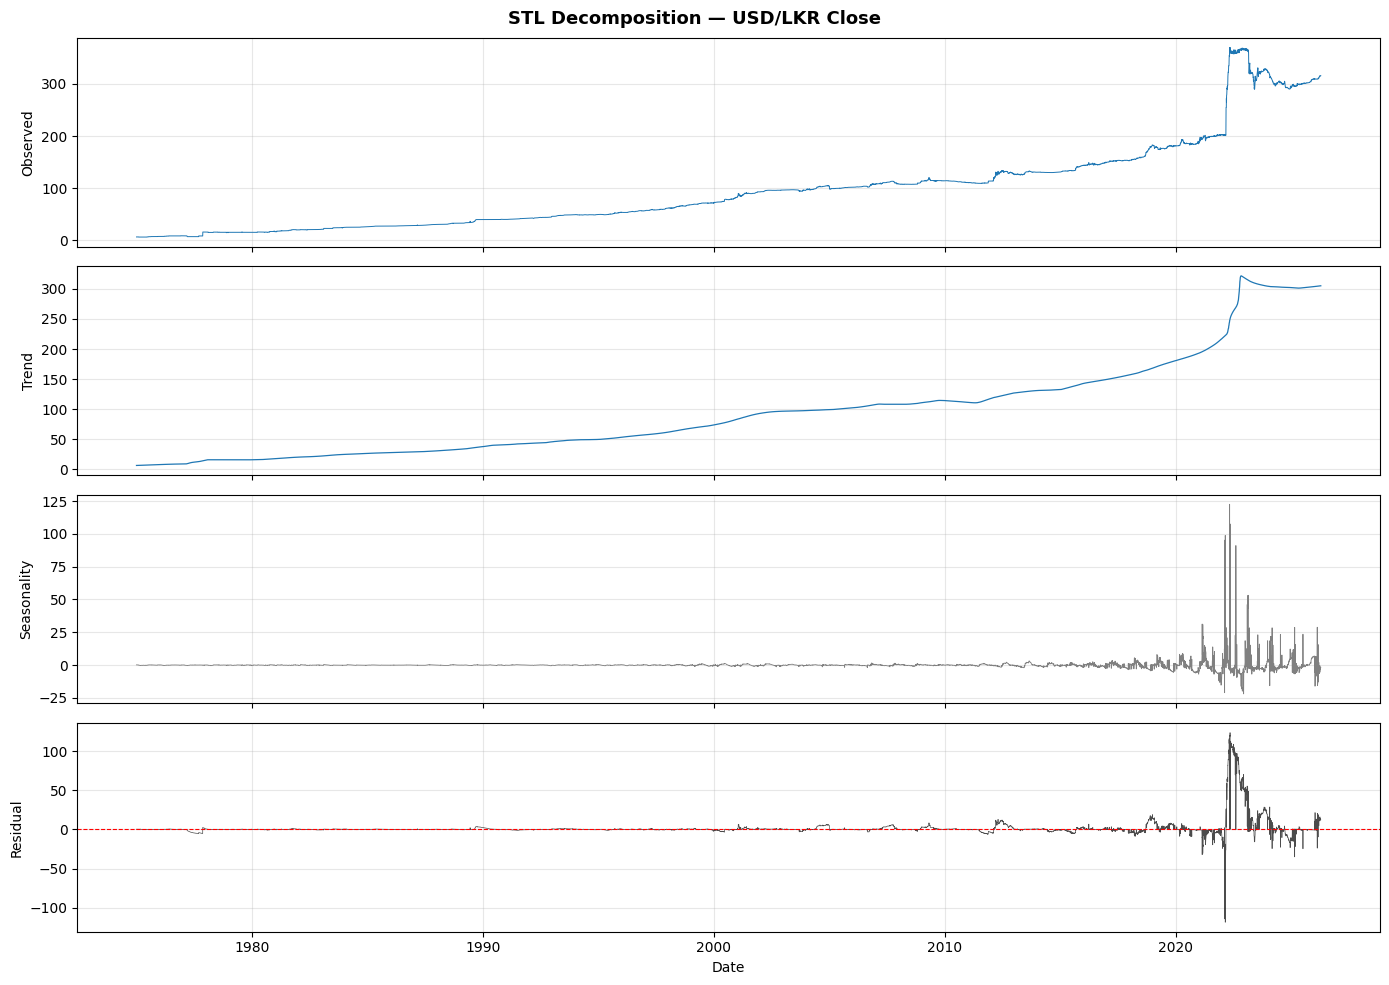

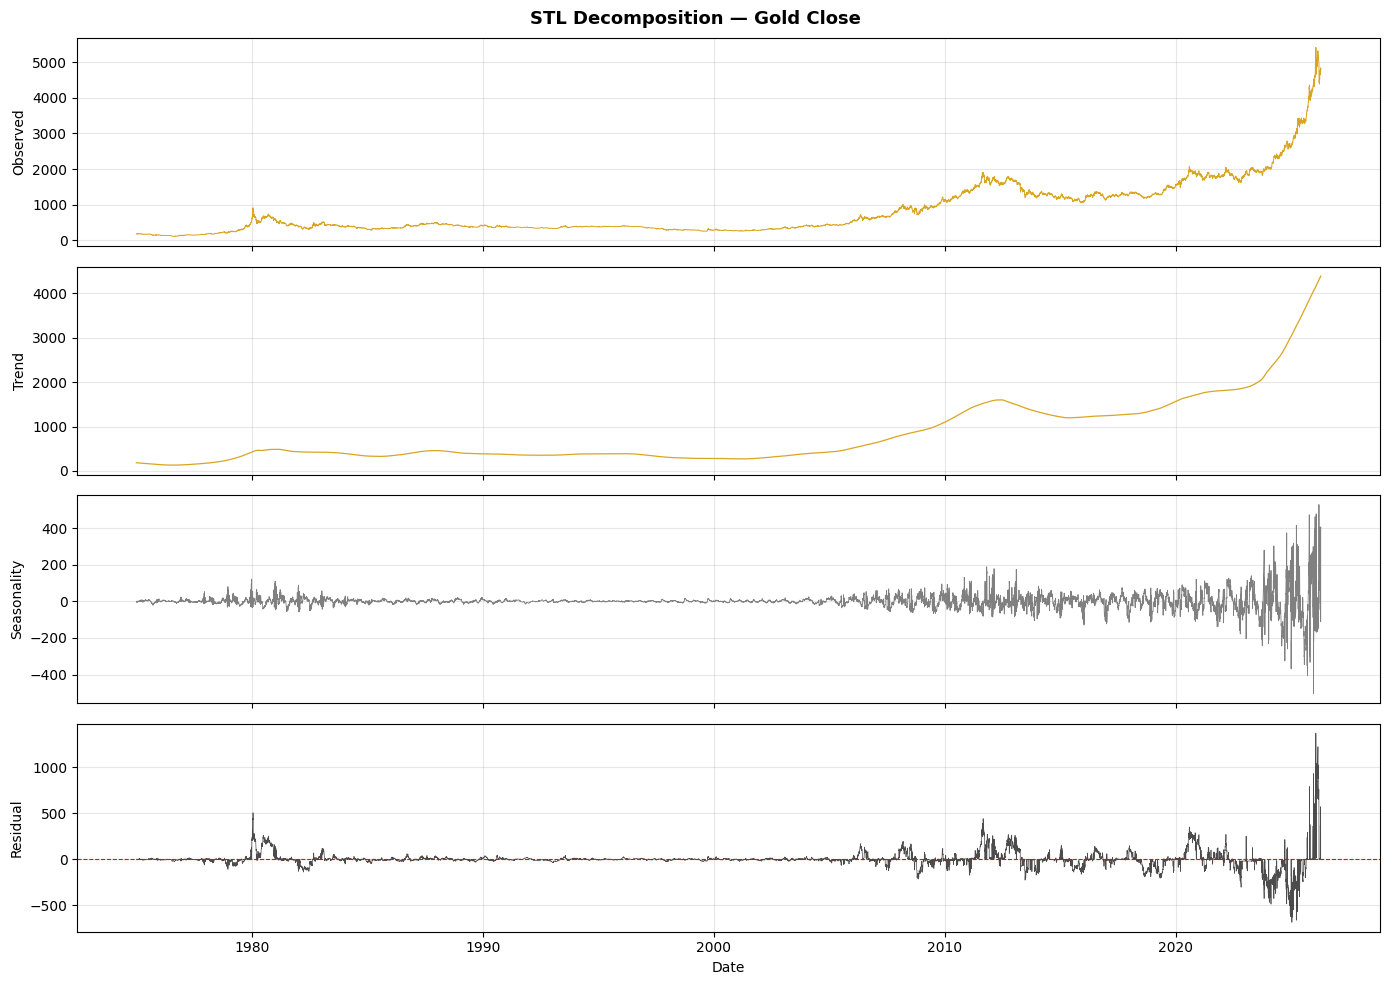

FORMAL CORRELATION ANALYSIS

 Pearson Correlation (raw prices) 
   r = 0.8550  |  p-value = 0.00e+00


In [10]:
# EDA 5: STL DECOMPOSITION

print("\n STL Decomposition ")

for series, label, color in [
    (df['lkr_close'],  'USD/LKR Close', '#1f77b4'),
    (df['gold_close'], 'Gold Close',    '#DAA520'),
]:
    stl = STL(series, period=252, robust=True)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'STL Decomposition — {label}', fontsize=13, fontweight='bold')

    axes[0].plot(series.index, series, color=color, linewidth=0.7)
    axes[0].set_ylabel('Observed')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(series.index, result.trend, color=color, linewidth=0.9)
    axes[1].set_ylabel('Trend')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(series.index, result.seasonal, color='grey', linewidth=0.6)
    axes[2].set_ylabel('Seasonality')
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(series.index, result.resid, color='black', linewidth=0.5, alpha=0.7)
    axes[3].axhline(0, color='red', linestyle='--', linewidth=0.8)
    axes[3].set_ylabel('Residual')
    axes[3].set_xlabel('Date')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = label.lower().replace('/', '').replace(' ', '_')
    plt.savefig(f'/content/drive/MyDrive/MSc_Project/outputs/02e_stl_{fname}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

# FORMAL CORRELATION 1: PEARSON (on raw prices — with caveat)

print("FORMAL CORRELATION ANALYSIS")

pearson_r, pearson_p = stats.pearsonr(df['lkr_close'], df['gold_close'])
print(f"\n Pearson Correlation (raw prices) ")
print(f"   r = {pearson_r:.4f}  |  p-value = {pearson_p:.2e}")


##### Interpretation:
* Very strong positive correlation ({pearson_r:.2f}),
stronger even than in the 2000-2022 subset (previously 0.71). This is spurious — both series trend upward over the full 50-year period, which inflates the raw-price correlation. This does NOT imply a causal or even meaningfully linear relationship.


 Spearman Correlation (log returns) 
   r = -0.0142  |  p-value = 0.1091
   Interpretation: No statistically significant linear correlation
   on daily log returns over the full history (p = 0.109).
   The relationship is likely non-linear and time-varying — see
   the rolling correlation plot above.


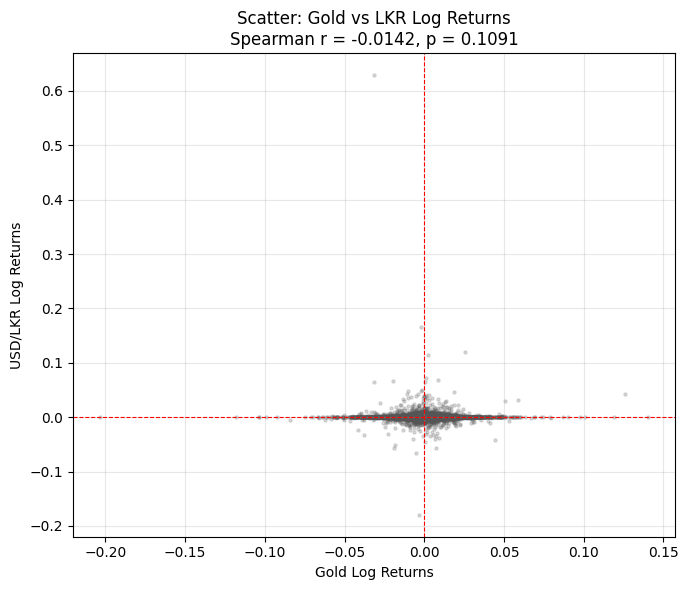


 Augmented Dickey-Fuller (ADF) Stationarity Test 
   H0: Series has a unit root (non-stationary)
   Reject H0 if p-value < 0.05

   USD/LKR Price          | ADF stat:   0.0908 | p: 0.9654 | NON-STATIONARY 
   Gold Price             | ADF stat:   5.3611 | p: 1.0000 | NON-STATIONARY 
   USD/LKR Returns        | ADF stat: -62.6110 | p: 0.0000 | STATIONARY 
   Gold Returns           | ADF stat: -19.0092 | p: 0.0000 | STATIONARY 


In [11]:
# FORMAL CORRELATION 2: SPEARMAN (on log returns — meaningful)

spearman_r, spearman_p = stats.spearmanr(df['lkr_returns'], df['gold_returns'])
print(f"\n Spearman Correlation (log returns) ")
print(f"   r = {spearman_r:.4f}  |  p-value = {spearman_p:.4f}")
if spearman_p < 0.05:
    print(f"   Interpretation: Statistically significant correlation on returns.")
else:
    print(f"   Interpretation: No statistically significant linear correlation")
    print(f"   on daily log returns over the full history (p = {spearman_p:.3f}).")
    print(f"   The relationship is likely non-linear and time-varying — see")
    print(f"   the rolling correlation plot above.")

# Scatter plot: returns
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df['gold_returns'], df['lkr_returns'],
           alpha=0.2, s=5, color='#555555')
ax.set_xlabel('Gold Log Returns')
ax.set_ylabel('USD/LKR Log Returns')
ax.set_title(f'Scatter: Gold vs LKR Log Returns\n'
             f'Spearman r = {spearman_r:.4f}, p = {spearman_p:.4f}')
ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax.axvline(0, color='red', linewidth=0.8, linestyle='--')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Project/outputs/02f_returns_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()

# FORMAL TEST 3: ADF STATIONARITY TEST

print(f"\n Augmented Dickey-Fuller (ADF) Stationarity Test ")
print(f"   H0: Series has a unit root (non-stationary)")
print(f"   Reject H0 if p-value < 0.05\n")

tests = [
    ('USD/LKR Price',    df['lkr_close']),
    ('Gold Price',       df['gold_close']),
    ('USD/LKR Returns',  df['lkr_returns']),
    ('Gold Returns',     df['gold_returns']),
]

for name, series in tests:
    result = adfuller(series, autolag='AIC')
    stat, p = result[0], result[1]
    conclusion = 'STATIONARY ' if p < 0.05 else 'NON-STATIONARY '
    print(f"   {name:<22} | ADF stat: {stat:>8.4f} | p: {p:.4f} | {conclusion}")



##### Key finding:
* Raw prices remain NON-STATIONARY over the full 50-year history (p ≈ 1.0 for both series — even stronger evidence of a unit root than in the shorter subset).
* Log returns ARE STATIONARY (p ≈ 0.00) for both series.
* Models must be trained on log returns, not raw prices.
* ARIMA will need d=1 differencing on price series.

In [12]:
# FORMAL TEST 4: GRANGER CAUSALITY TEST

print(f"\n Granger Causality Test ")
print(f"   H0: Gold returns do NOT Granger-cause USD/LKR returns")
print(f"   Reject H0 if p-value < 0.05\n")

gc_results = grangercausalitytests(
    df[['lkr_returns', 'gold_returns']], maxlag=5, verbose=False
)

for lag, result in gc_results.items():
    f_stat = result[0]['ssr_ftest'][0]
    p_val  = result[0]['ssr_ftest'][1]
    sig    = '* Marginally significant' if p_val < 0.10 else ''
    sig    = '** Significant'           if p_val < 0.05 else sig
    print(f"   Lag {lag}: F-stat = {f_stat:.4f}  |  p = {p_val:.4f}  {sig}")




 Granger Causality Test 
   H0: Gold returns do NOT Granger-cause USD/LKR returns
   Reject H0 if p-value < 0.05

   Lag 1: F-stat = 2.1965  |  p = 0.1383  
   Lag 2: F-stat = 1.9049  |  p = 0.1489  
   Lag 3: F-stat = 1.4357  |  p = 0.2302  
   Lag 4: F-stat = 1.1114  |  p = 0.3491  
   Lag 5: F-stat = 0.9173  |  p = 0.4684  


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


##### Key finding:
* Over the full 50-year history, Granger causalityfrom gold to LKR returns is NOT statistically significant at any of lags 1-5 (all p > 0.10). This differs from the earlier 2000-2022 subset, where lags 3-5 showed marginal significance.
* The earlier result was likely driven disproportionately by the 2022 crisis period; diluted across 50 years of mostly calm,policy-managed exchange rate behaviour, the average effect is no longer detectable by a simple linear Granger test.
* This itself is an important finding: it suggests gold's predictive relationship with LKR is CRISIS-DEPENDENT rather than a stable, ever-present linear effect, reinforcing the case for a flexible, non-linear model (LSTM/GRU/XGBoost) over a simple linear approach.

In [13]:
# FORMAL TEST 5: ENGLE-GRANGER COINTEGRATION TEST

print(f"\n  Engle-Granger Cointegration Test ")
print(f"   H0: No cointegration (no long-run equilibrium relationship)")
print(f"   Reject H0 if p-value < 0.05\n")

score, p_val, _ = coint(df['lkr_close'], df['gold_close'])
print(f"   Cointegration stat: {score:.4f}  |  p = {p_val:.4f}")
if p_val < 0.05:
    print(f"    COINTEGRATED: a long-run equilibrium relationship exists.")
    print(f"    Consider an Error Correction Model (ECM) extension.")
else:
    print(f"    NOT COINTEGRATED (p = {p_val:.4f} >> 0.05).")
    print(f"    No stable long-run equilibrium between the two series, even")
    print(f"    when tested over the full 50-year history.")
    print(f"    The relationship is time-varying and crisis-driven,")
    print(f"      which is why a flexible deep learning model is appropriate.")

# SUMMARY TABLE

print(f"SUMMARY OF STATISTICAL FINDINGS (FULL 1975-2026 DATASET)")
print(f"{'Test':<35} {'Result':<18} {'Implication'}")

print(f"{'Pearson (raw prices)':<35} {'r=0.86 ***':<18} Spurious - shared trend")
print(f"{'Spearman (log returns)':<35} {'r=-0.014':<18} No linear daily relationship")
print(f"{'ADF - LKR price':<35} {'Non-stationary':<18} Needs differencing")
print(f"{'ADF - Gold price':<35} {'Non-stationary':<18} Needs differencing")
print(f"{'ADF - LKR returns':<35} {'Stationary':<18} Ready for modelling")
print(f"{'ADF - Gold returns':<35} {'Stationary':<18} Ready for modelling")
print(f"{'Granger (lags 1-5)':<35} {'Not significant':<18} No stable linear lag effect")
print(f"{'Cointegration':<35} {'Not cointegrated':<18} Time-varying relationship")
print(f"{'Rolling correlation':<35} {'Time-varying':<18} Non-static, crisis-driven")



  Engle-Granger Cointegration Test 
   H0: No cointegration (no long-run equilibrium relationship)
   Reject H0 if p-value < 0.05

   Cointegration stat: -1.8680  |  p = 0.5961
    NOT COINTEGRATED (p = 0.5961 >> 0.05).
    No stable long-run equilibrium between the two series, even
    when tested over the full 50-year history.
    The relationship is time-varying and crisis-driven,
      which is why a flexible deep learning model is appropriate.
SUMMARY OF STATISTICAL FINDINGS (FULL 1975-2026 DATASET)
Test                                Result             Implication
Pearson (raw prices)                r=0.86             Spurious - shared trend
Spearman (log returns)              r=-0.014           No linear daily relationship
ADF - LKR price                     Non-stationary     Needs differencing
ADF - Gold price                    Non-stationary     Needs differencing
ADF - LKR returns                   Stationary        Ready for modelling
ADF - Gold returns                  S

##### Conclusion:
* Across the full 50-year history, gold shows no stable, always-present linear relationship with LKR - the earlier marginal.
* Granger result was specific to the 2000-2022 window and likely
 driven by the 2022 crisis period. The relationship instead appears
to be regime-dependent, intensifying during global stress events.
* This further strengthens the case for a flexible hybrid model(LSTM/GRU/XGBoost) capable of learning crisis-dependent, non-linear patterns, rather than a simple linear model assuming a constant gold-LKR relationship across all market regimes.